# Week 5 · Notebook 1 — Gaussian Process Regression From Scratch

## Learning objectives

1. View a Gaussian process (GP) as a prior over functions specified by a mean function $m(x)$ and a covariance kernel $k(x, x')$.
2. Derive the **predictive distribution** for noisy observations using only Gaussian conditioning.
3. Implement GP regression in NumPy with Cholesky for numerical stability.
4. Visualise prior samples, posterior samples, and predictive credible bands.

---

## 1. Definition and conditioning identity

A Gaussian process is a distribution over functions such that any finite collection $\{f(x_n)\}_{n=1}^N$ is jointly Gaussian. We write
$$
f \sim \mathcal{GP}(m, k),\qquad m(x) = \mathbb{E}[f(x)],\quad k(x, x') = \mathrm{Cov}(f(x), f(x')).
$$
Below we use the squared-exponential (RBF) kernel
$$
k(x, x') = \sigma_f^2 \exp\Bigl(-\tfrac{1}{2\ell^2}\Vert x - x'\Vert^2\Bigr).
$$

Suppose we observe $y_n = f(x_n) + \varepsilon_n$ with $\varepsilon_n\sim\mathcal{N}(0,\sigma_n^2)$. Stack $X$, $y$ for training points and $X_*$ for test points. The joint distribution of $y$ and $f_* = f(X_*)$ is
$$
\begin{bmatrix} y \\ f_* \end{bmatrix}
\sim \mathcal{N}\Biggl(0,\;
\begin{bmatrix} K + \sigma_n^2 I & K_* \\ K_*^\top & K_{**} \end{bmatrix}
\Biggr).
$$
Gaussian conditioning gives the **predictive**
$$
\boxed{\;\mu_*(X_*) = K_*^\top (K+\sigma_n^2 I)^{-1} y,\qquad
\Sigma_*(X_*) = K_{**} - K_*^\top (K+\sigma_n^2 I)^{-1} K_*.\;}
$$

For numerical stability we never invert $K+\sigma_n^2 I$ directly. We Cholesky-decompose $L L^\top = K+\sigma_n^2 I$ and solve two triangular systems.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve

rng = np.random.default_rng(0)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN = '#5B7DB1', '#C46D5E', '#7CA982'


In [2]:
def rbf(X1, X2, sigma_f=1.0, ell=1.0):
    d2 = np.sum(X1**2, axis=1)[:, None] + np.sum(X2**2, axis=1)[None, :] - 2*X1 @ X2.T
    return (sigma_f**2) * np.exp(-0.5 * d2 / ell**2)

class GPRegressor:
    def __init__(self, sigma_f=1.0, ell=1.0, sigma_n=0.1):
        self.sigma_f, self.ell, self.sigma_n = sigma_f, ell, sigma_n

    def fit(self, X, y):
        X = np.atleast_2d(X); X = X if X.shape[1] >= 1 else X.T
        self.X_, self.y_ = X, y
        K = rbf(X, X, self.sigma_f, self.ell) + self.sigma_n**2 * np.eye(len(X))
        self.L_ = np.linalg.cholesky(K + 1e-9*np.eye(len(X)))
        self.alpha_ = cho_solve((self.L_, True), y)
        return self

    def predict(self, Xs, return_cov=False):
        Xs = np.atleast_2d(Xs); Xs = Xs if Xs.shape[1] >= 1 else Xs.T
        Ks = rbf(self.X_, Xs, self.sigma_f, self.ell)
        Kss = rbf(Xs, Xs, self.sigma_f, self.ell)
        mu = Ks.T @ self.alpha_
        v = cho_solve((self.L_, True), Ks)
        cov = Kss - Ks.T @ v
        if return_cov:
            return mu, cov
        return mu, np.sqrt(np.maximum(np.diag(cov), 0.0))

    def log_marginal_likelihood(self):
        n = len(self.y_)
        return (-0.5 * self.y_ @ self.alpha_
                - np.sum(np.log(np.diag(self.L_)))
                - 0.5 * n * np.log(2*np.pi))


## 2. Prior samples

Before seeing data, sample directly from $f\sim\mathcal{N}(0, K_{**})$ to build intuition for the kernel.


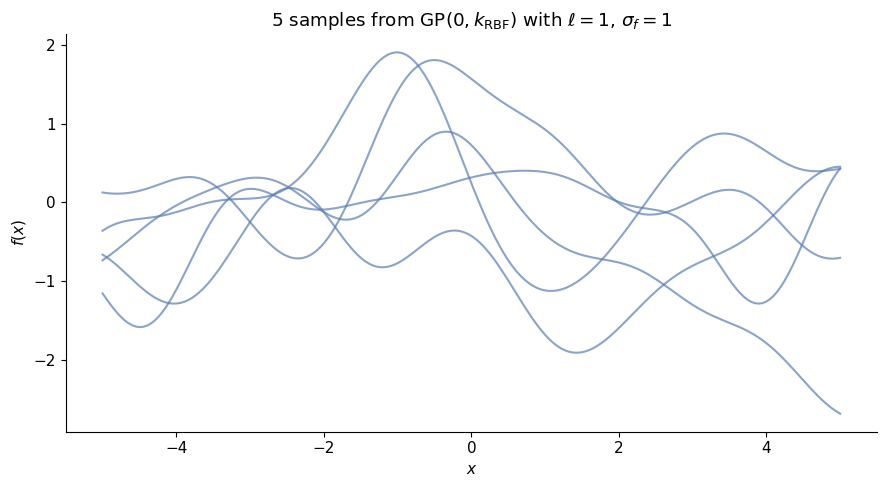

In [3]:
xs = np.linspace(-5, 5, 200).reshape(-1, 1)
Kss = rbf(xs, xs, sigma_f=1.0, ell=1.0)
L = np.linalg.cholesky(Kss + 1e-9*np.eye(len(xs)))

plt.figure()
for i in range(5):
    z = rng.normal(size=len(xs))
    plt.plot(xs.ravel(), L @ z, color=BLUE, alpha=0.7)
plt.title(r'5 samples from $\mathrm{GP}(0, k_{\mathrm{RBF}})$ with $\ell=1$, $\sigma_f=1$')
plt.xlabel('$x$'); plt.ylabel('$f(x)$'); plt.tight_layout(); plt.show()


## 3. Posterior on a small noisy dataset


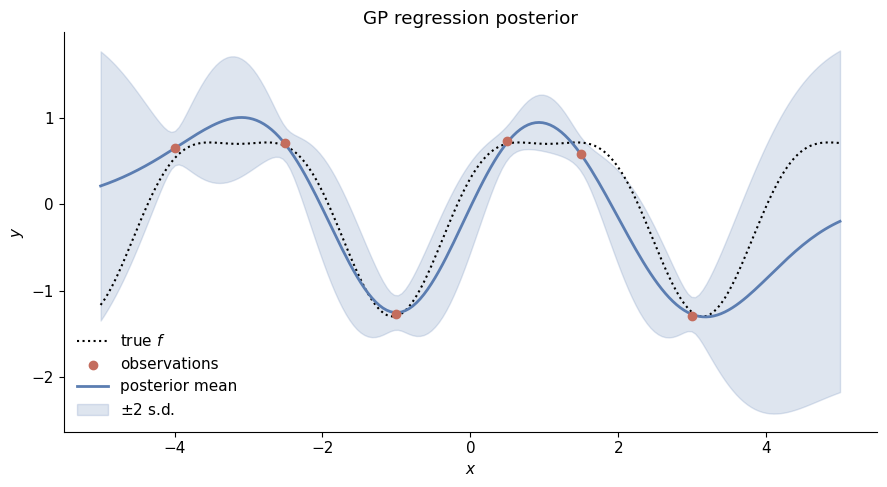

log marginal likelihood = -8.397177283917607


In [4]:
def f_true(x):
    return np.sin(1.5 * x) + 0.3 * np.cos(3 * x)

X_train = np.array([-4.0, -2.5, -1.0, 0.5, 1.5, 3.0]).reshape(-1, 1)
y_train = f_true(X_train).ravel() + 0.1 * rng.normal(size=len(X_train))

gp = GPRegressor(sigma_f=1.0, ell=1.0, sigma_n=0.1).fit(X_train, y_train)
mu, sd = gp.predict(xs)

plt.figure()
plt.plot(xs.ravel(), f_true(xs).ravel(), 'k:', label='true $f$')
plt.scatter(X_train, y_train, color=RED, zorder=5, label='observations')
plt.plot(xs.ravel(), mu, color=BLUE, lw=2, label='posterior mean')
plt.fill_between(xs.ravel(), mu - 2*sd, mu + 2*sd, alpha=0.2, color=BLUE,
                 label=r'$\pm 2$ s.d.')
plt.legend(frameon=False); plt.xlabel('$x$'); plt.ylabel('$y$')
plt.title('GP regression posterior')
plt.tight_layout(); plt.show()
print('log marginal likelihood =', gp.log_marginal_likelihood())


## 4. Posterior samples — the function-space view

Drawing samples from the posterior makes the GP's structured uncertainty visible. Near training points the samples collapse onto the data; between them they fan out.


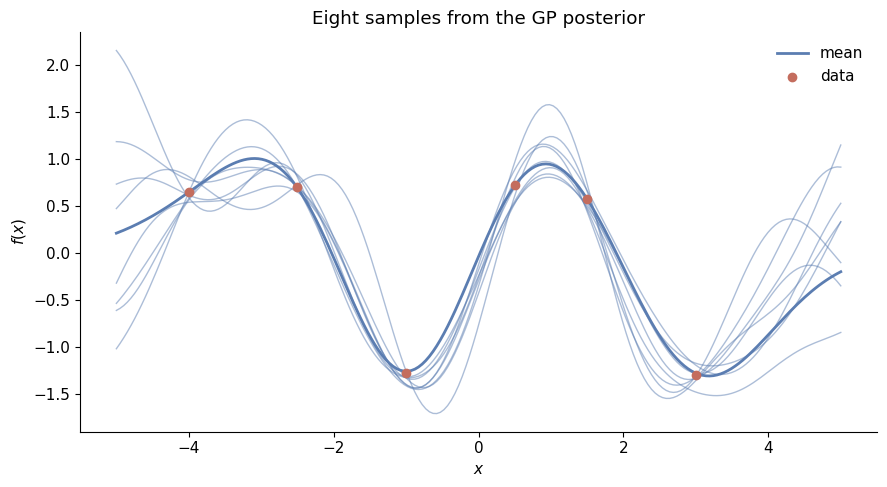

In [5]:
mu_post, cov_post = gp.predict(xs, return_cov=True)
Lp = np.linalg.cholesky(cov_post + 1e-9*np.eye(len(xs)))

plt.figure()
for i in range(8):
    z = rng.normal(size=len(xs))
    plt.plot(xs.ravel(), mu_post + Lp @ z, color=BLUE, alpha=0.5, lw=1)
plt.plot(xs.ravel(), mu_post, color=BLUE, lw=2, label='mean')
plt.scatter(X_train, y_train, color=RED, zorder=5, label='data')
plt.legend(frameon=False); plt.title('Eight samples from the GP posterior')
plt.xlabel('$x$'); plt.ylabel('$f(x)$'); plt.tight_layout(); plt.show()


## 5. Comparison with scikit-learn


In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

ker = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e3))
sk = GaussianProcessRegressor(kernel=ker, alpha=0.1**2,
                              optimizer=None, normalize_y=False)
sk.fit(X_train, y_train)
mu_sk, sd_sk = sk.predict(xs, return_std=True)

print('mean L_inf  difference:', np.max(np.abs(mu - mu_sk)))
print('sd   L_inf  difference:', np.max(np.abs(sd - sd_sk)))


mean L_inf  difference: 2.0331860639544175e-09
sd   L_inf  difference: 4.907368095219411e-09


## 6. Summary

- A GP turns a kernel into a non-parametric prior over functions.
- Conditioning on noisy observations yields a closed-form Gaussian predictive — the cubic Cholesky factorisation cost is the price.
- Posterior samples reveal coherent uncertainty between data points.
- Our from-scratch implementation matches sklearn to numerical precision when hyper-parameters are held fixed.

---

## Exercises

1. Derive the posterior mean and variance for a single test point $x_*$ by hand, without matrix notation, for the case $N=2$.
2. Show that the GP posterior mean equals the kernel ridge regression solution with regularisation $\lambda = \sigma_n^2$.
3. Implement a *centred* GP whose mean function is a quadratic polynomial. Show that this is equivalent to adding a polynomial kernel to the RBF.
4. Extend `GPRegressor` to compute the predictive *log-likelihood* of held-out test data and use it to compare $(\ell=0.5)$ vs $(\ell=2.0)$ on the data above.
